In [52]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("../outputs")

holdout_features = pd.read_parquet(
    OUTPUT_DIR / "holdout_features.parquet"
)

graph_result = pd.read_csv(
    OUTPUT_DIR / "anomaly_graph_score.csv"
)

assert holdout_features["CustomerID"].is_unique
assert graph_result["CustomerID"].is_unique

holdout_features.shape, graph_result.shape

((20000, 117), (20000, 11))

In [53]:
def is_binary_series(s: pd.Series) -> bool:
    values = set(s.dropna().unique())
    return values.issubset({0, 1, 0.0, 1.0})


def percentile_risk(
    df: pd.DataFrame,
    col: str,
    high_is_risk: bool = True,
) -> pd.Series:
    """
    Chuyển 1 feature về risk score [0, 1]

    high_is_risk=True:
        large value = risky

    high_is_risk=False:
        large value = trustworthy/safe
    """
    s = pd.to_numeric(df[col], errors="coerce")

    if s.isna().all():
        return pd.Series(0.0, index=df.index)

    # Median imputation
    s = s.fillna(s.median())

    # Cứ 1 là rủi ro cao nhất, 0 là an toàn nhất
    if is_binary_series(s):
        risk = s.astype(float) if high_is_risk else 1.0 - s.astype(float)
        return risk.clip(0, 1)

    # Nếu tất cả giá trị đều bẳng nhau, không có risk signal
    if s.nunique(dropna=True) <= 1:
        return pd.Series(0.0, index=df.index)

    pct = s.rank(method="average", pct=True)

    risk = pct if high_is_risk else 1.0 - pct

    return risk.clip(0, 1)


def weighted_mean_risk(
    df: pd.DataFrame,
    specs: list[tuple[str, bool, float]],
    prefix: str,
) -> tuple[pd.Series, pd.DataFrame]:
    """
    specs = [(feature_name, high_is_risk, weight), ...]
    """
    component_df = pd.DataFrame(index=df.index)
    weighted_sum = pd.Series(0.0, index=df.index)
    total_weight = 0.0

    for col, high_is_risk, weight in specs:
        if col not in df.columns:
            continue

        risk = percentile_risk(
            df=df,
            col=col,
            high_is_risk=high_is_risk,
        )

        component_name = f"{prefix}_{col}_risk"
        component_df[component_name] = risk

        weighted_sum += weight * risk
        total_weight += weight

    if total_weight == 0:
        pillar_risk = pd.Series(0.0, index=df.index)
    else:
        pillar_risk = weighted_sum / total_weight

    return pillar_risk.clip(0, 1), component_df

In [54]:
STRONG = 1.5
MEDIUM = 1.0
WEAK = 0.5
CONTEXT = 0.25


# 1. Device Integrity
# high_is_risk=True means larger value is riskier.
# high_is_risk=False means larger value is safer.

device_specs = [
    # Direct device compromise / automation signals
    ("is_emulator", True, STRONG),
    ("emulator_session_ratio", True, STRONG),
    ("tac_grey_clone_flag", True, STRONG),

    # Rooted/jailbroken device signals
    ("is_rooted", True, MEDIUM),
    ("rooted_session_ratio", True, MEDIUM),

    # Device reputation / TAC-level risk
    ("tac_risk_score", True, MEDIUM),

    # Shared device signals
    ("high_shared_imei_flag", True, MEDIUM),
    ("max_customers_per_imei", True, MEDIUM),
    ("shared_imei_flag", True, WEAK),

    # Weaker context signals
    ("low_tier_device_flag", True, WEAK),
    ("low_tier_session_ratio", True, WEAK),
    ("num_imeis_90d", True, WEAK),
]


# 2. SIM Stability

sim_specs = [
    # Direct SIM-swap risk signals
    ("sim_swap_count_90d", True, STRONG),
    ("days_since_last_sim_swap", False, STRONG),  # smaller = riskier
    ("recent_sim_change_flag", True, STRONG),

    # Broader SIM instability signals
    ("sim_swap_count_12m", True, MEDIUM),
    ("iccid_count", True, MEDIUM),

    # Weaker context signals
    ("phone_number_age_days", False, WEAK),       # newer number = riskier
    ("port_in_flag", True, WEAK),
]


# 3. Behavioral Consistency

behavior_specs = [
    # Strong risky infrastructure / impossible-travel-like signals
    ("geo_velocity_alerts_30d", True, STRONG),
    ("datacenter_ratio_30d", True, STRONG),
    ("vpn_proxy_ratio_30d", True, STRONG),

    # Main behavioral consistency signals
    ("geo_velocity_flag_30d", True, MEDIUM),
    ("non_residential_ratio_30d", True, MEDIUM),
    ("home_cell_ratio_30d", False, MEDIUM),       # higher home stability = safer
    ("distinct_country_30d", True, MEDIUM),

    # Secondary behavior signals
    ("distinct_ip_30d", True, WEAK),
    ("night_session_ratio_30d", True, WEAK),

    # Context only: high activity may be legitimate power-user behavior
    ("avg_sessions_per_day_30d", True, CONTEXT),
    ("total_sessions_30d", True, CONTEXT),
]


# 4. Identity Confidence

identity_specs = [
    # Strong identity confidence signal
    ("kyc_level_ord", False, STRONG),

    # Main verification availability signals
    ("has_face_score", False, MEDIUM),
    ("has_iddoc_score", False, MEDIUM),

    # Match quality signals
    ("face_match_score", False, STRONG),
    ("id_doc_match_score", False, STRONG),
]

In [55]:
dts_base = holdout_features[["CustomerID"]].copy()

device_risk, device_components = weighted_mean_risk(
    holdout_features,
    device_specs,
    prefix="device",
)

sim_risk, sim_components = weighted_mean_risk(
    holdout_features,
    sim_specs,
    prefix="sim",
)

behavior_risk, behavior_components = weighted_mean_risk(
    holdout_features,
    behavior_specs,
    prefix="behavior",
)

identity_risk, identity_components = weighted_mean_risk(
    holdout_features,
    identity_specs,
    prefix="identity",
)

dts_base["device_risk"] = device_risk
dts_base["sim_risk"] = sim_risk
dts_base["behavior_risk"] = behavior_risk
dts_base["identity_risk"] = identity_risk

# Chuyển risk thành trust score: high score = more trustworthy
dts_base["device_score"] = 1000 * (1 - dts_base["device_risk"])
dts_base["sim_score"] = 1000 * (1 - dts_base["sim_risk"])
dts_base["behavior_score"] = 1000 * (1 - dts_base["behavior_risk"])
dts_base["identity_score"] = 1000 * (1 - dts_base["identity_risk"])

dts_base.head()

,CustomerID,device_risk,sim_risk,behavior_risk,identity_risk,device_score,sim_score,behavior_score,identity_score
0,3000006,0.254765,0.259387,0.368606,0.645529,745.234783,740.613333,631.393750,354.471154
1,3000018,0.245610,0.475340,0.445371,0.333981,754.390217,524.660000,554.628750,666.019231
2,3000034,0.685204,0.520685,0.392980,0.364667,314.795652,479.315000,607.020000,635.332692
3,3000070,0.143949,0.325973,0.566254,0.120138,856.051087,674.026667,433.745625,879.861538
4,3000074,0.143949,0.259593,0.470479,0.106910,856.051087,740.406667,529.520625,893.090385


In [56]:
pillar_weights = {
    "device_score": 0.25,
    "sim_score": 0.30,
    "behavior_score": 0.25,
    "identity_score": 0.20,
}

dts_base["DTS_unsup"] = (
    pillar_weights["device_score"] * dts_base["device_score"]
    + pillar_weights["sim_score"] * dts_base["sim_score"]
    + pillar_weights["behavior_score"] * dts_base["behavior_score"]
    + pillar_weights["identity_score"] * dts_base["identity_score"]
)

dts_base["DTS_unsup"] = (
    dts_base["DTS_unsup"]
    .clip(0, 1000)
    .round()
    .astype(int)
)

dts_base[
    [
        "CustomerID",
        "device_score",
        "sim_score",
        "behavior_score",
        "identity_score",
        "DTS_unsup",
    ]
].head()

,CustomerID,device_score,sim_score,behavior_score,identity_score,DTS_unsup
0,3000006,745.234783,740.613333,631.393750,354.471154,637
1,3000018,754.390217,524.660000,554.628750,666.019231,618
2,3000034,314.795652,479.315000,607.020000,635.332692,501
3,3000070,856.051087,674.026667,433.745625,879.861538,701
4,3000074,856.051087,740.406667,529.520625,893.090385,747


In [57]:
score_output = dts_base.merge(
    graph_result[
        [
            "CustomerID",
            "anomaly_score",
            "graph_adjusted_anomaly_score",
        ]
    ],
    on="CustomerID",
    how="left",
)

score_output["AnomalyScore"] = score_output["graph_adjusted_anomaly_score"]

submission_unsup = score_output[
    [
        "CustomerID",
        "AnomalyScore",
        "DTS_unsup",
    ]
].copy()

submission_unsup.head()

,CustomerID,AnomalyScore,DTS_unsup
0,3000006,0.916227,637
1,3000018,0.648253,618
2,3000034,0.996780,501
3,3000070,0.919107,701
4,3000074,0.389682,747


In [58]:
assert len(submission_unsup) == len(holdout_features)
assert submission_unsup["CustomerID"].is_unique
assert submission_unsup["AnomalyScore"].between(0, 1).all()
assert submission_unsup["DTS_unsup"].between(0, 1000).all()

submission_unsup.shape

(20000, 3)

In [59]:
submission_unsup["DTS_unsup"].describe()

count    20000.00000
mean       618.71810
std         79.44944
min        266.00000
25%        569.00000
50%        626.00000
75%        682.00000
max        773.00000
Name: DTS_unsup, dtype: float64

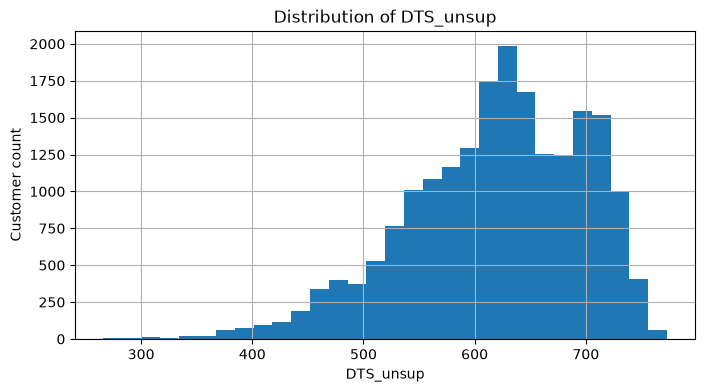

In [60]:
plt.figure(figsize=(8, 4))
plt.hist(submission_unsup["DTS_unsup"], bins=30)
plt.xlabel("DTS_unsup")
plt.ylabel("Customer count")
plt.title("Distribution of DTS_unsup")
plt.grid(True)
plt.show()

In [61]:
submission_unsup[["AnomalyScore", "DTS_unsup"]].corr(method="spearman")

,AnomalyScore,DTS_unsup
AnomalyScore,1.000000,-0.378417
DTS_unsup,-0.378417,1.000000


In [63]:
extreme_cols = [
    "CustomerID",
    "AnomalyScore",
    "DTS_unsup",
    "device_score",
    "sim_score",
    "behavior_score",
    "identity_score",
    "device_risk",
    "sim_risk",
    "behavior_risk",
    "identity_risk",
]

score_output[extreme_cols].nsmallest(
    20,
    "DTS_unsup",
)

,CustomerID,AnomalyScore,DTS_unsup,device_score,sim_score,behavior_score,identity_score,device_risk,sim_risk,behavior_risk,identity_risk
17622,3356802,0.981492,266,305.670652,120.478333,551.981250,76.338462,0.694329,0.879522,0.448019,0.923662
19544,3390754,0.928468,267,402.302174,74.806667,263.860625,390.165385,0.597698,0.925193,0.736139,0.609835
10053,3202282,0.993430,270,402.302174,156.048333,429.709375,76.338462,0.597698,0.843952,0.570291,0.923662
9992,3201230,0.906373,271,392.178261,84.055000,530.378750,76.338462,0.607822,0.915945,0.469621,0.923662
11382,3229674,0.938098,271,391.907609,77.630000,266.680000,413.005769,0.608092,0.922370,0.733320,0.586994
3442,3069734,0.941608,273,220.482609,136.231667,452.628750,320.311538,0.779517,0.863768,0.547371,0.679688
3788,3077146,0.894762,280,402.302174,121.510000,512.515625,76.338462,0.597698,0.878490,0.487484,0.923662
13317,3269706,0.927163,282,402.302174,136.086667,321.681250,299.692308,0.597698,0.863913,0.678319,0.700308
8780,3176982,0.930763,286,402.302174,157.108333,285.774375,333.580769,0.597698,0.842892,0.714226,0.666419
9041,3182022,0.934543,288,390.880435,121.598333,552.270625,76.338462,0.609120,0.878402,0.447729,0.923662


In [64]:
score_output[extreme_cols].nlargest(
    20,
    "DTS_unsup",
)

,CustomerID,AnomalyScore,DTS_unsup,device_score,sim_score,behavior_score,identity_score,device_risk,sim_risk,behavior_risk,identity_risk
8503,3171402,0.158832,773,856.051087,708.796667,650.701875,917.788462,0.143949,0.291203,0.349298,0.082212
102,3002354,0.908937,771,856.051087,740.068333,607.020000,917.788462,0.143949,0.259932,0.392980,0.082212
1782,3035742,0.799902,771,856.051087,733.543333,624.850000,904.271154,0.143949,0.266457,0.375150,0.095729
6553,3132182,0.464788,769,856.051087,721.678333,644.996875,885.521154,0.143949,0.278322,0.355003,0.114479
8397,3168986,0.819868,768,856.051087,703.890000,650.701875,899.032692,0.143949,0.296110,0.349298,0.100967
19708,3393638,0.135747,767,856.051087,735.876667,626.496250,879.625000,0.143949,0.264123,0.373504,0.120375
566,3011286,0.717372,766,856.051087,738.626667,626.758125,867.653846,0.143949,0.261373,0.373242,0.132346
2946,3058954,0.213237,766,856.051087,725.393333,627.794375,888.613462,0.143949,0.274607,0.372206,0.111387
19549,3390802,0.373482,766,856.051087,730.570000,596.476250,917.788462,0.143949,0.269430,0.403524,0.082212
3203,3064394,0.247977,765,856.051087,727.075000,596.476250,917.788462,0.143949,0.272925,0.403524,0.082212


In [65]:
score_output[extreme_cols].nlargest(
    20,
    "AnomalyScore",
)

,CustomerID,AnomalyScore,DTS_unsup,device_score,sim_score,behavior_score,identity_score,device_risk,sim_risk,behavior_risk,identity_risk
2593,3052314,0.999945,448,323.446739,729.440000,357.288750,295.117308,0.676553,0.270560,0.642711,0.704883
584,3011570,0.999938,384,323.446739,739.028333,264.426875,76.338462,0.676553,0.260972,0.735573,0.923662
16779,3339522,0.999543,364,323.446739,627.580000,320.250000,76.338462,0.676553,0.372420,0.679750,0.923662
19942,3398714,0.999533,393,323.446739,734.410000,305.784375,76.338462,0.676553,0.265590,0.694216,0.923662
11460,3231562,0.999238,452,323.446739,703.890000,401.391875,296.351923,0.676553,0.296110,0.598608,0.703648
11779,3238626,0.999208,394,323.446739,149.696667,401.076250,837.642308,0.676553,0.850303,0.598924,0.162358
14556,3295838,0.998740,381,249.511957,694.246667,380.978125,76.338462,0.750488,0.305753,0.619022,0.923662
11503,3232406,0.998695,463,768.544565,493.901667,428.075625,76.338462,0.231455,0.506098,0.571924,0.923662
1163,3023474,0.998605,453,249.511957,733.543333,447.287500,295.359615,0.750488,0.266457,0.552712,0.704640
376,3007294,0.998483,339,403.332609,329.318333,497.273125,76.338462,0.596667,0.670682,0.502727,0.923662


In [66]:
score_output[
    (score_output["AnomalyScore"] >= score_output["AnomalyScore"].quantile(0.96))
    & (score_output["DTS_unsup"] >= score_output["DTS_unsup"].quantile(0.75))
][extreme_cols].sort_values("AnomalyScore", ascending=False).head(20)

,CustomerID,AnomalyScore,DTS_unsup,device_score,sim_score,behavior_score,identity_score,device_risk,sim_risk,behavior_risk,identity_risk
5507,3111026,0.985795,716,768.544565,713.246667,554.995625,856.559615,0.231455,0.286753,0.445004,0.143440
10376,3209150,0.984255,691,768.544565,701.116667,544.467500,759.959615,0.231455,0.298883,0.455533,0.240040
486,3009646,0.968210,716,770.498913,738.626667,580.457500,784.715385,0.229501,0.261373,0.419543,0.215285
15789,3319730,0.963835,696,770.498913,697.850000,531.848750,804.723077,0.229501,0.302150,0.468151,0.195277
6662,3134082,0.959055,686,746.805435,644.285000,574.226250,813.325000,0.253195,0.355715,0.425774,0.186675
683,3013298,0.958675,701,768.544565,670.446667,618.188750,763.651923,0.231455,0.329553,0.381811,0.236348
4296,3087442,0.958080,687,657.304348,729.440000,585.307500,785.944231,0.342696,0.270560,0.414693,0.214056
553,3011014,0.941562,710,856.051087,672.361667,589.511250,736.328846,0.143949,0.327638,0.410489,0.263671
9567,3192810,0.940177,710,856.051087,713.246667,482.731250,808.455769,0.143949,0.286753,0.517269,0.191544
3731,3076046,0.940172,709,834.311957,728.300000,518.811250,761.811538,0.165688,0.271700,0.481189,0.238188


In [67]:
score_output[
    (score_output["DTS_unsup"] <= score_output["DTS_unsup"].quantile(0.10))
    & (score_output["AnomalyScore"] <= score_output["AnomalyScore"].quantile(0.50))
][extreme_cols].sort_values("DTS_unsup").head(20)

,CustomerID,AnomalyScore,DTS_unsup,device_score,sim_score,behavior_score,identity_score,device_risk,sim_risk,behavior_risk,identity_risk
10317,3207730,0.443908,329,402.302174,72.806667,516.212500,388.809615,0.597698,0.927193,0.483787,0.611190
12365,3250646,0.488322,371,402.302174,336.101667,618.188750,76.338462,0.597698,0.663898,0.381811,0.923662
9486,3190998,0.359758,387,754.390217,154.068333,549.169375,76.338462,0.245610,0.845932,0.450831,0.923662
18641,3375078,0.392653,396,754.390217,125.791667,618.188750,76.338462,0.245610,0.874208,0.381811,0.923662
13099,3265266,0.438057,407,402.302174,134.316667,527.891875,671.938462,0.597698,0.865683,0.472108,0.328062
9542,3192250,0.416683,414,856.051087,152.828333,555.636250,76.338462,0.143949,0.847172,0.444364,0.923662
8487,3170978,0.426270,415,316.750000,472.616667,532.655625,302.219231,0.683250,0.527383,0.467344,0.697781
5169,3104106,0.462537,425,402.302174,370.691667,538.086250,395.351923,0.597698,0.629308,0.461914,0.604648
12720,3257642,0.496512,425,220.932609,694.246667,583.292500,76.338462,0.779067,0.305753,0.416707,0.923662
12326,3249734,0.395217,427,754.390217,110.063333,505.815000,394.180769,0.245610,0.889937,0.494185,0.605819


In [68]:
submission_unsup.to_csv(
    OUTPUT_DIR / "trackA_holdout_submission.csv",
    index=False,
)

score_output.to_csv(
    OUTPUT_DIR / "dts_unsup_with_pillars.csv",
    index=False,
)

print("Saved:")
print(OUTPUT_DIR / "trackA_holdout_submission.csv")
print(OUTPUT_DIR / "dts_unsup_with_pillars.csv")

Saved:
../outputs/trackA_holdout_submission.csv
../outputs/dts_unsup_with_pillars.csv
